In [19]:
!pip install kagglehub[pandas-datasets] -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

sns.set_theme(style="whitegrid")
print("Sedang mengunduh dataset dari Kaggle...")
file_path = "Country-data.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "rohan0301/unsupervised-learning-on-country-data",
    file_path,
)

print("Berhasil memuat data dari 167 negara!")

display(df[['country', 'life_expec', 'income']].head())

Sedang mengunduh dataset dari Kaggle...


/tmp/ipykernel_32671/1253465843.py:15: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Berhasil memuat data dari 167 negara!


,country,life_expec,income
0,Afghanistan,56.2,1610
1,Albania,76.3,9930
2,Algeria,76.5,12900
3,Angola,60.1,5900
4,Antigua and Barbuda,76.8,19100


In [20]:
from sklearn.preprocessing import StandardScaler

X = df[['life_expec', 'income']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Contoh 5 data pertama setelah distandarisasi: ")
print(X_scaled[:5])

Contoh 5 data pertama setelah distandarisasi: 
[[-1.61909203 -0.8082454 ]
 [ 0.64786643 -0.3753689 ]
 [ 0.67042323 -0.22084447]
 [-1.17923442 -0.58504345]
 [ 0.70425843  0.10173177]]


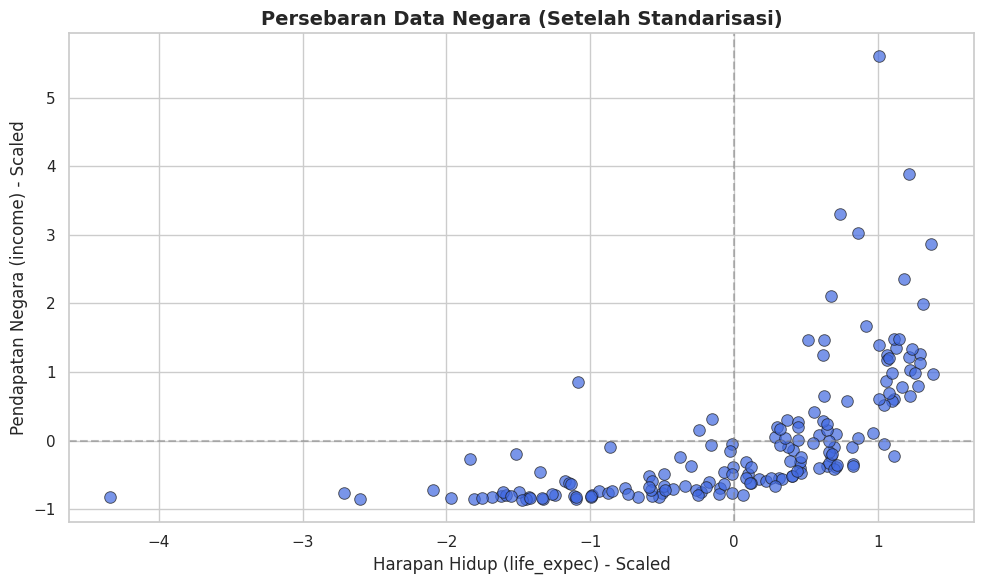

In [21]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    color='royalblue',
    s=70,
    alpha=0.7,
    edgecolor='k'
)

plt.title("Persebaran Data Negara (Setelah Standarisasi)", fontsize=14, fontweight='bold')
plt.xlabel("Harapan Hidup (life_expec) - Scaled", fontsize=12)
plt.ylabel("Pendapatan Negara (income) - Scaled", fontsize=12)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [22]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.2, min_samples=3)

labels = dbscan.fit_predict(X_scaled)

df['Cluster'] = labels

print("DBSCAN berhasil dijalankan!")
print("\nRingkasan Hasil Pembagian Klaster (CLuster ID : Jumlah Negara): ")
print(df['Cluster'].value_counts().sort_index())

DBSCAN berhasil dijalankan!

Ringkasan Hasil Pembagian Klaster (CLuster ID : Jumlah Negara): 
Cluster
-1     26
 0    117
 1     24
Name: count, dtype: int64


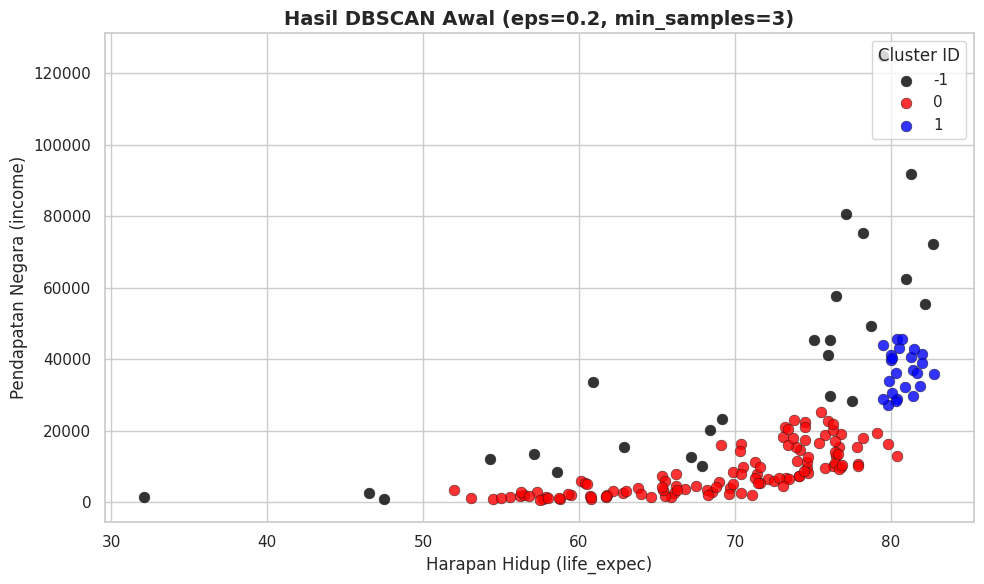

In [23]:
plt.figure(figsize=(10, 6))

unique_labels = sorted(df['Cluster'].unique())

colors = {-1: 'black', 0: 'red'}

for label in unique_labels:
    mask = df['Cluster'] == label
    color = colors.get(label, 'blue')
    plt.scatter(
        df.loc[mask, 'life_expec'],
        df.loc[mask, 'income'],
        c=color,
        s=60,
        alpha=0.8,
        edgecolors='k',
        linewidths=0.4,
        label=str(label)
    )

plt.title("Hasil DBSCAN Awal (eps=0.2, min_samples=3)", fontsize=14, fontweight='bold')
plt.xlabel("Harapan Hidup (life_expec)", fontsize=12)
plt.ylabel("Pendapatan Negara (income)", fontsize=12)
plt.legend(title="Cluster ID", loc="upper right")
plt.tight_layout()
plt.show()

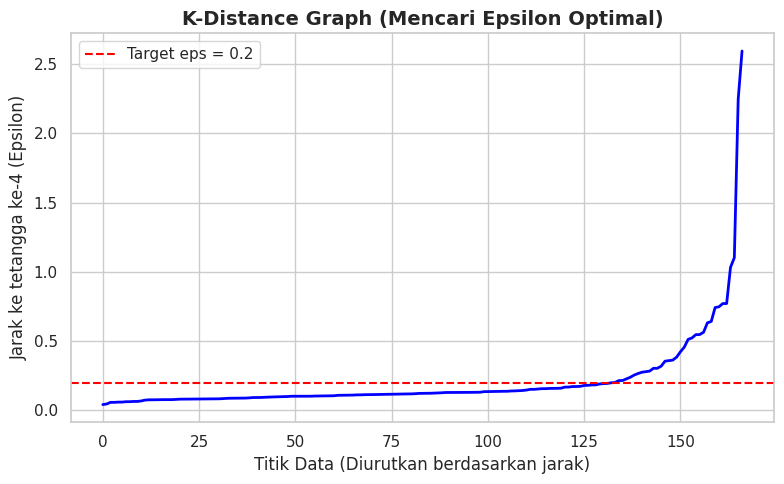

In [36]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 3], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances, color='blue', linewidth=2)

plt.title("K-Distance Graph (Mencari Epsilon Optimal)", fontsize=14, fontweight='bold')
plt.xlabel("Titik Data (Diurutkan berdasarkan jarak)", fontsize=12)
plt.ylabel("Jarak ke tetangga ke-4 (Epsilon)", fontsize=12)

plt.axhline(y=0.2, color='red', linestyle='--', label='Target eps = 0.2')

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

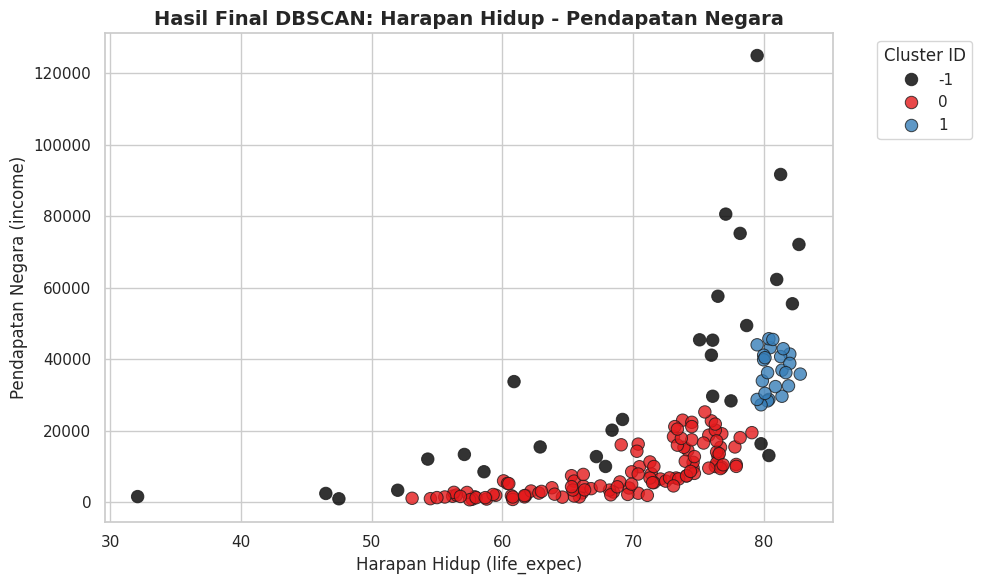

DISTRIBUSI NEGARA PADA KLASTER FINAL: 
Cluster_Final
-1     29
 0    114
 1     24
Name: count, dtype: int64


In [35]:
dbscan_final = DBSCAN(eps=0.2, min_samples=4)
df['Cluster_Final'] = dbscan_final.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
unique_clusters_final = len(np.unique(df['Cluster_Final']))
palette_final = sns.color_palette("Set1", unique_clusters_final - 1)
palette_final.insert(0, (0.0, 0.0, 0.0))

sns.scatterplot(
    x=df['life_expec'],
    y=df['income'],
    hue=df['Cluster_Final'],
    palette=palette_final,
    s=80,
    alpha=0.8,
    edgecolor='k'
)

plt.title("Hasil Final DBSCAN: Harapan Hidup - Pendapatan Negara", fontsize=14, fontweight='bold')
plt.xlabel("Harapan Hidup (life_expec)", fontsize=12)
plt.ylabel("Pendapatan Negara (income)", fontsize=12)
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("DISTRIBUSI NEGARA PADA KLASTER FINAL: ")
print(df['Cluster_Final'].value_counts().sort_index())